# Final Model Evaluation and Error Analysis (V3)

This is an error-analysis stage, not a tuning or model-selection experiment. It retains the fixed XGBoost configuration from V1/V2 and generates repeated out-of-fold predictions using 5 stratified folds x 5 repeats. It reports aggregate held-out metrics, per-class precision/recall/F1, count and normalised confusion matrices, probability-confidence diagnostics, high-confidence errors, and the closest cross-label DGA pairs from V2.5.

No hyperparameters, data values, features, asset use, or timestamps are changed.

V3 final fixed-model evaluation and error analysis
The V1/V2 XGBoost configuration is used without tuning. Scores are repeated out-of-fold predictions only; asset/time are not predictive features.



1. Repeated out-of-fold aggregate performance


,evaluation,accuracy,balanced_accuracy,macro_f1,weighted_f1,mean_fold_macro_f1,fold_macro_f1_sd
0,OOF repeated-CV aggregate,0.2533,0.2499,0.2482,0.2508,0.2627,0.0392


This aggregate combines five held-out probability predictions per observation. Mean fold macro-F1 remains the primary V2 comparison quantity.


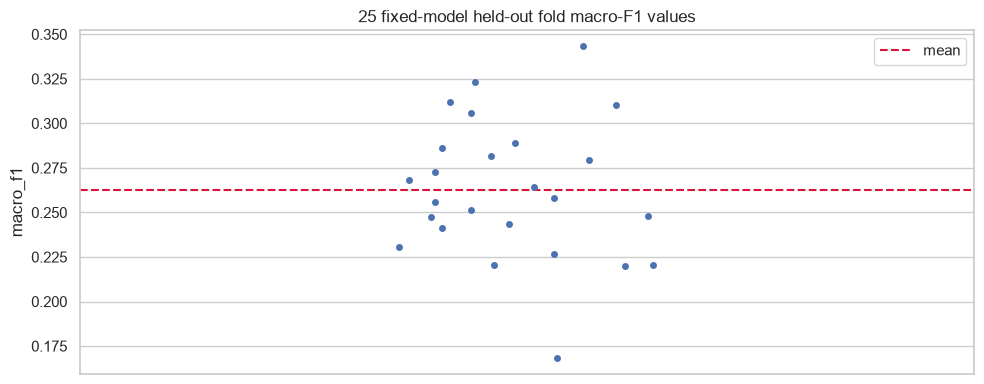


2. Per-class held-out error analysis


,precision,recall,f1,support
Non-determinable,0.2167,0.2063,0.2114,63.0
Normal,0.2784,0.3103,0.2935,87.0
Partial Discharge,0.1471,0.1316,0.1389,76.0
Thermal Fault,0.3467,0.3514,0.3490,74.0


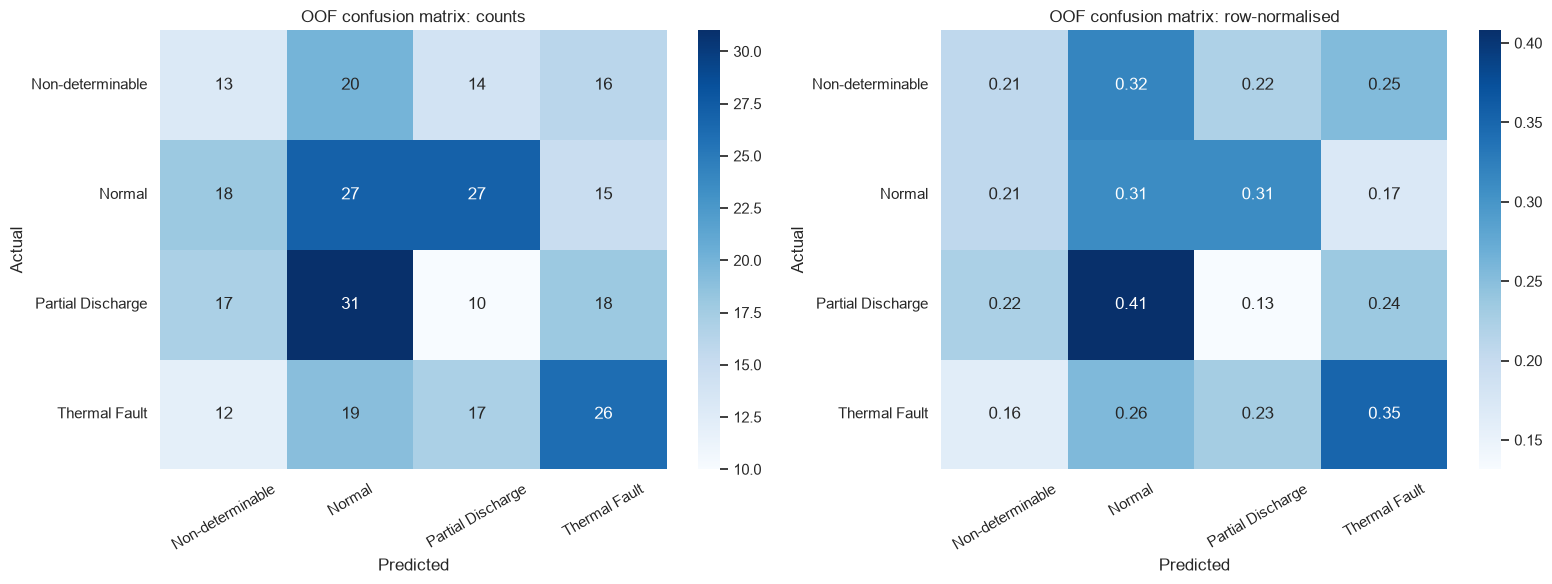

Most frequent off-diagonal errors


,actual_class,predicted_class,count,within_actual_class_rate
7,Partial Discharge,Normal,31,0.4079
4,Normal,Partial Discharge,27,0.3103
0,Non-determinable,Normal,20,0.3175
10,Thermal Fault,Normal,19,0.2568
8,Partial Discharge,Thermal Fault,18,0.2368
3,Normal,Non-determinable,18,0.2069
11,Thermal Fault,Partial Discharge,17,0.2297
6,Partial Discharge,Non-determinable,17,0.2237
2,Non-determinable,Thermal Fault,16,0.2540
5,Normal,Thermal Fault,15,0.1724



3. Probability-confidence diagnostic


,count,mean,median,min,max
correct,,,,,
False,224,0.4232,0.4059,0.2706,0.7616
True,76,0.4306,0.4068,0.2768,0.6520


,confidence_bin,n,accuracy,mean_confidence
0,"(0.249, 0.34]",56,0.1786,0.3162
1,"(0.34, 0.43]",128,0.2891,0.3857
2,"(0.43, 0.52]",60,0.2000,0.4670
3,"(0.52, 0.61]",45,0.3111,0.5603
4,"(0.61, 0.7]",9,0.3333,0.6362


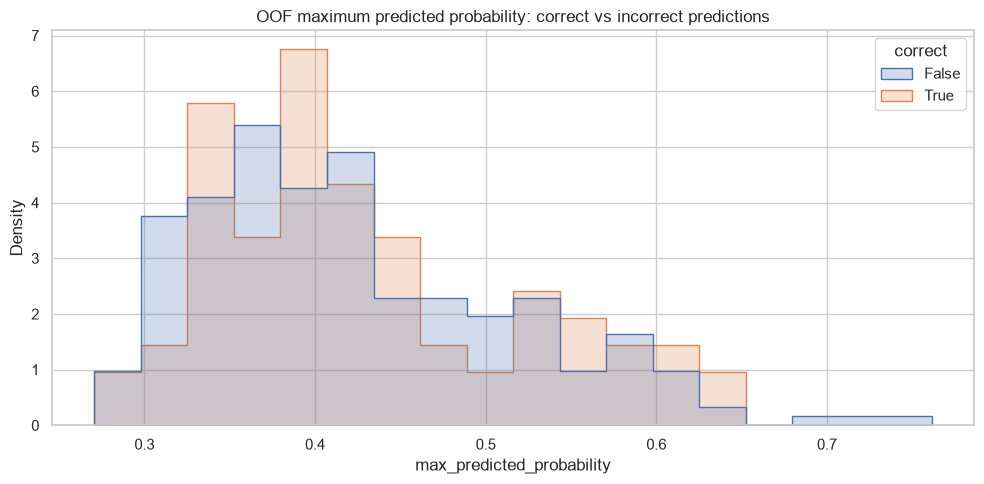

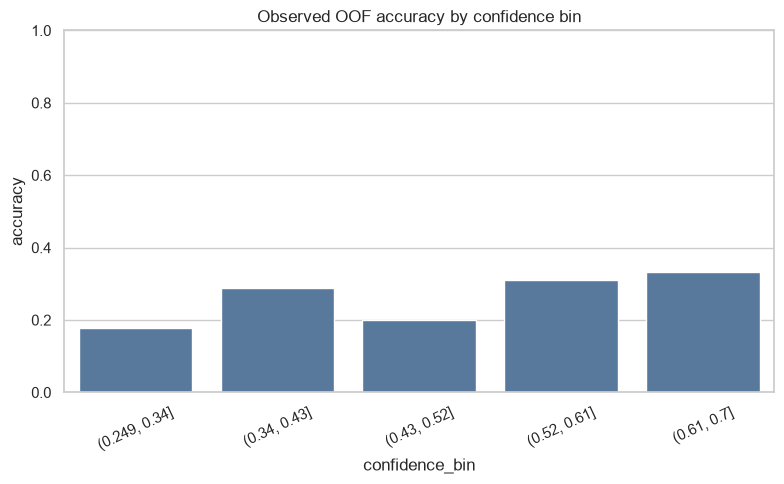

Mean one-vs-rest Brier score: 0.2001 (descriptive probability-quality measure; not a tuning target).

4. Closest cross-label DGA pairs from V2.5 feature geometry


,row_id_a,actual_a,OOF_pred_a,confidence_a,row_id_b,actual_b,OOF_pred_b,confidence_b,standardised_DGA_distance
0,203,Normal,Partial Discharge,0.532,207,Partial Discharge,Normal,0.344,0.7537
1,190,Non-determinable,Thermal Fault,0.477,212,Thermal Fault,Non-determinable,0.558,0.7599
2,5,Non-determinable,Partial Discharge,0.420,7,Thermal Fault,Normal,0.361,0.8901
3,49,Thermal Fault,Thermal Fault,0.454,67,Partial Discharge,Non-determinable,0.627,0.9239
4,118,Normal,Partial Discharge,0.397,155,Thermal Fault,Thermal Fault,0.446,0.9432
5,165,Normal,Partial Discharge,0.573,186,Thermal Fault,Partial Discharge,0.359,0.9609
6,206,Normal,Partial Discharge,0.358,214,Non-determinable,Normal,0.452,0.9626
7,36,Partial Discharge,Normal,0.363,51,Normal,Non-determinable,0.453,0.9821
8,239,Partial Discharge,Non-determinable,0.444,279,Non-determinable,Partial Discharge,0.347,0.9896
9,245,Normal,Thermal Fault,0.347,287,Non-determinable,Non-determinable,0.289,1.0264


These are qualitative failure evidence only: a pair may not itself be misclassified, but close different labels demonstrate target overlap in observed feature space.

5. Fifteen most confident incorrect OOF predictions


,row_id,asset,ts_H2,fault_by_rogers,oof_prediction,max_predicted_probability
103,104,TX_B,2025-01-05 07:00:00,Normal,Thermal Fault,0.7616
182,183,TX_A,2025-01-08 14:00:00,Thermal Fault,Partial Discharge,0.7318
106,107,TX_B,2025-01-05 10:00:00,Partial Discharge,Normal,0.6892
20,21,TX_C,2025-01-01 20:00:00,Normal,Non-determinable,0.6377
66,67,TX_B,2025-01-03 18:00:00,Partial Discharge,Non-determinable,0.6265
68,69,TX_C,2025-01-03 20:00:00,Non-determinable,Partial Discharge,0.6236
274,275,TX_C,2025-01-12 10:00:00,Normal,Non-determinable,0.6193
152,153,TX_A,2025-01-07 08:00:00,Partial Discharge,Normal,0.6167
284,285,TX_B,2025-01-12 20:00:00,Thermal Fault,Non-determinable,0.6085
1,2,TX_B,2025-01-01 01:00:00,Thermal Fault,Non-determinable,0.6065


V3 FINAL ERROR-ANALYSIS CONCLUSION
The fixed XGBoost model produces substantial, class-specific held-out confusion. Its probability concentration and high-confidence errors should be interpreted alongside V2's failed permutation gate and V2.5's absent local label consistency. These results characterise failure; they do not justify tuning.


In [1]:
%run v3_final_error_analysis.py